In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIG_DIR = FIGURES_DIR
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / 'results'
BETH_DIR = DATA_DIR / 'Beth'
UNSW_DIR = DATA_DIR / 'unsw_nb15' / 'CSV Files'
CYBER_DIR = DATA_DIR / 'Cyber_Attacks'

paths = {
    'unsw_train': UNSW_DIR / 'UNSW_NB15_training-set.csv',
    'unsw_test': UNSW_DIR / 'UNSW_NB15_testing-set.csv',
    'beth_train': BETH_DIR / 'labelled_training_data.csv',
    'beth_test': BETH_DIR / 'labelled_testing_data.csv',
    'cyber': CYBER_DIR / 'cybersecurity_attacks.csv',
}

dfs = {}
dfs['unsw_train'] = pd.read_csv(paths['unsw_train'])
dfs['unsw_test'] = pd.read_csv(paths['unsw_test'])
dfs['beth_train'] = pd.read_csv(paths['beth_train'])
dfs['beth_test'] = pd.read_csv(paths['beth_test'])
dfs['cyber'] = pd.read_csv(paths['cyber'])

unsw_train_df = dfs['unsw_train']
unsw_test_df = dfs['unsw_test']
beth_train_df = dfs['beth_train']
beth_test_df = dfs['beth_test']
cyber_df = dfs['cyber']

print('All datasets loaded successfully.')
for k, v in dfs.items():
    print(f'  {k}: {v.shape}')


All datasets loaded successfully.
  unsw_train: (175341, 45)
  unsw_test: (82332, 45)
  beth_train: (763144, 16)
  beth_test: (188967, 16)
  cyber: (40000, 25)


# **UNSW-NB15 Dataset – Supervised Attack Classification**

## **Purpose**
For the UNSW-NB15 dataset, my goal was to build a supervised machine learning pipeline that can detect malicious network traffic and classify the specific attack type. Since this dataset includes labeled attacks, I approached it as a standard supervised learning problem. The main purpose of this section of my capstone is to design a realistic SOC-style workflow where the model first identifies whether traffic is malicious and then predicts the exact category of attack.

---

## **Approach**

I structured my approach into two major stages:

### **1. Binary Attack Detection (Stage 1)**
I trained several supervised models to classify each network flow as *normal* or *attack*:

- **Logistic Regression** – my linear baseline model  
- **Random Forest** – handles non-linear patterns and provides feature importance  
- **XGBoost** – my strongest gradient-boosting model for tabular data  

Each model was evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices. This established the performance baseline for Stage 1.

---

### **2. Attack-Type Classification (Stage 2)**  
Once a flow was predicted as malicious, the next task was to classify the attack type. I trained models **only on attack samples** and applied **SMOTE oversampling** to handle severe class imbalance across attack categories (e.g., Shellcode, Worms, Backdoor).

I evaluated these models using per-class F1 scores, weighted averages, confusion matrices, and feature importance rankings. This two-stage setup mirrors how real intrusion detection systems operate.

---

## **Training Strategy**

I followed a systematic, multi-step training workflow:

### **1. Load and preprocess the UNSW-NB15 dataset**
- Extracted numeric and categorical features  
- Encoded categorical variables  
- Standardized numerical features  

### **2. Train baseline models**
I trained logistic regression, random forest, and XGBoost with default hyperparameters to establish a baseline.

### **3. Evaluate baseline models**
I assessed each model on the test set to measure initial performance.

### **4. Hyperparameter tuning**
I applied GridSearch or RandomizedSearch on the validation set and optimized for weighted F1-score to prevent overfitting.

### **5. Re-train tuned models**
Each tuned model was retrained on the full training set and evaluated again on the test set.

### **6. Build a two-stage pipeline**
Stage 1 → detect attack  
Stage 2 → classify attack type (with SMOTE)

### **7. End-to-end pipeline evaluation**
I combined both stages and measured how well the full system performed when operating sequentially.

---

## **Table of Contents**

1. **Setup and Data Loading**  
2. **Prepare Features and Labels**  
3. **Train Baseline Models**  
4. **Evaluate Baseline Models on Test Set**  
   - 4.1 Logistic Regression  
   - 4.2 Random Forest  
   - 4.3 XGBoost  
5. **Compare Baseline Models**  
6. **Hyperparameter Tuning**  
   - 6.1 Tune Logistic Regression  
   - 6.2 Tune Random Forest  
   - 6.3 Tune XGBoost  
   - 6.4 Compare Tuned vs Baseline Models  
7. **Evaluate Tuned Models on Test Set**  
8. **Two-Stage Prediction Pipeline**  
   - 8.1 Stage 1: Binary Attack Detection  
   - 8.2 Stage 2: Attack-Type Classification (with SMOTE)  
   - 8.3 End-to-End Pipeline Evaluation  
9. **Save Results**  
10. **Summary and Conclusions**



In [2]:
# In this cell I set up my imports and quickly confirm that my UNSW data is loaded.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

# ---- SAFE XGBOOST IMPORT (updated) ----
try:
    import xgboost as xgb
    print("XGBoost successfully imported.")
except ModuleNotFoundError:
    xgb = None
    print("WARNING: XGBoost is not installed. XGBoost-based models will be skipped.")
# ---------------------------------------

# If I'm running inside the capstone project, I should already have load_unsw available
# either from: `from data_loading import load_unsw` OR because I defined it earlier.
try:
    # Try to use the helper from my src/data_loading.py module
    from data_loading import load_unsw
    unsw_train_raw, unsw_test_raw = load_unsw()
except ModuleNotFoundError:
    # Fallback: load directly from the raw CSV paths if the import fails
    import platform
    from pathlib import Path

    if platform.system() == "Windows":
        base_unsw = Path(
            r"C:\Users\kegem\OneDrive\Datascience Masters\DS Summer 2025 SEMESTER 3"
            r"\DX799S O1 Data Science Capstone (Summer 1 2025)\Network Security DataSet"
            r"\CSV Files\Training and Testing Sets"
        )
    else:
        base_unsw = Path(
            "/Users/kevinegemba/Library/CloudStorage/OneDrive-Personal/"
            "Datascience Masters/DS Summer 2025 SEMESTER 3/"
            "DX799S O1 Data Science Capstone (Summer 1 2025)/"
            "Network Security DataSet/CSV Files/Training and Testing Sets"
        )

    train_path = base_unsw / "UNSW_NB15_training-set.csv"
    test_path  = base_unsw / "UNSW_NB15_testing-set.csv"

    unsw_train_raw = pd.read_csv(train_path)
    unsw_test_raw  = pd.read_csv(test_path)

# I set a global random seed so results are reproducible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Train shape:", unsw_train_raw.shape)
print("Test shape :", unsw_test_raw.shape)
print("\nColumns:", list(unsw_train_raw.columns))

# Quick check that 'label' exists and is binary
print("\nLabel value counts (train):")
print(unsw_train_raw['label'].value_counts(dropna=False))
print("\nLabel value counts (test):")
print(unsw_test_raw['label'].value_counts(dropna=False))


XGBoost successfully imported.
Train shape: (175341, 45)
Test shape : (82332, 45)

Columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Label value counts (train):
label
1    119341
0     56000
Name: count, dtype: int64

Label value counts (test):
label
1    45332
0    37000
Name: count, dtype: int64


In [3]:
# In this cell I prepare my UNSW features and the binary target for Stage 1.

# I assume unsw_train_raw and unsw_test_raw are already loaded in memory.
print("Training shape:", unsw_train_raw.shape)
print("Test shape     :", unsw_test_raw.shape)

# I double-check that the expected target columns exist
expected_cols = ['label', 'attack_cat']
for col in expected_cols:
    print(f"{col} in train? {col in unsw_train_raw.columns}")
    print(f"{col} in test?  {col in unsw_test_raw.columns}")
    print("-" * 40)

# For Stage 1 I use the binary 'label' column: 0 = normal, 1 = attack
y_full = unsw_train_raw['label'].copy()
y_test_bin = unsw_test_raw['label'].copy()

# I drop columns that should NOT be used as features at this stage:
# - 'label' (target leakage)
# - 'attack_cat' (multi-class label used in Stage 2)
cols_to_drop = ['label']
if 'attack_cat' in unsw_train_raw.columns:
    cols_to_drop.append('attack_cat')

X_full = unsw_train_raw.drop(columns=cols_to_drop)
X_test_raw = unsw_test_raw.drop(columns=cols_to_drop)

print("\nFeature matrix shapes:")
print("  X_full (train+val):", X_full.shape)
print("  X_test_raw        :", X_test_raw.shape)

# Train/validation split from the training partition
from sklearn.model_selection import train_test_split

X_train_raw, X_val_raw, y_train_bin, y_val_bin = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=RANDOM_STATE
)

print("\nFinal splits:")
print("  X_train_raw:", X_train_raw.shape)
print("  X_val_raw  :", X_val_raw.shape)
print("  y_train_bin:", y_train_bin.shape)
print("  y_val_bin  :", y_val_bin.shape)

# I separate numeric and categorical feature columns so I can build a clean preprocessing pipeline.
numeric_cols = X_train_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()

print("\nNumeric feature count   :", len(numeric_cols))
print("Categorical feature count:", len(categorical_cols))


Training shape: (175341, 45)
Test shape     : (82332, 45)
label in train? True
label in test?  True
----------------------------------------
attack_cat in train? True
attack_cat in test?  True
----------------------------------------

Feature matrix shapes:
  X_full (train+val): (175341, 43)
  X_test_raw        : (82332, 43)

Final splits:
  X_train_raw: (140272, 43)
  X_val_raw  : (35069, 43)
  y_train_bin: (140272,)
  y_val_bin  : (35069,)

Numeric feature count   : 40
Categorical feature count: 3


In [4]:
# In this cell I build a ColumnTransformer that:
# - standardizes numeric features
# - one-hot encodes categorical features
# This lets me plug the same preprocessing into all supervised models.

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop"
)

print(preprocessor)


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['id', 'dur', 'spkts', 'dpkts', 'sbytes',
                                  'dbytes', 'rate', 'sttl', 'dttl', 'sload',
                                  'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt',
                                  'sjit', 'djit', 'swin', 'stcpb', 'dtcpb',
                                  'dwin', 'tcprtt', 'synack', 'ackdat', 'smean',
                                  'dmean', 'trans_depth', 'response_body_len',
                                  'ct_srv_src', 'ct_state_ttl', ...]),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['proto', 'service', 'state'])])


XGBoost successfully imported – I will train an XGBoost model as well.
UNSW train/test already found in memory. I will reuse them.

UNSW shapes:
  Train: (175341, 45)
  Test : (82332, 45)

Feature matrix shapes:
  X_train_full: (175341, 44)
  X_test_full : (82332, 44)

Number of numeric features   : 40
Number of categorical features: 4

Models I am about to train: ['logistic_regression', 'random_forest', 'xgboost']

################################################################################
FITTING BASELINE MODEL: logistic_regression
################################################################################

Evaluating model: logistic_regression
Accuracy : 0.9981
Precision: 1.0000
Recall   : 0.9966
F1-score : 0.9983
ROC-AUC  : 1.0000

Classification report:
              precision    recall  f1-score   support

           0      0.996     1.000     0.998     37000
           1      1.000     0.997     0.998     45332

    accuracy                          0.998     82332
   

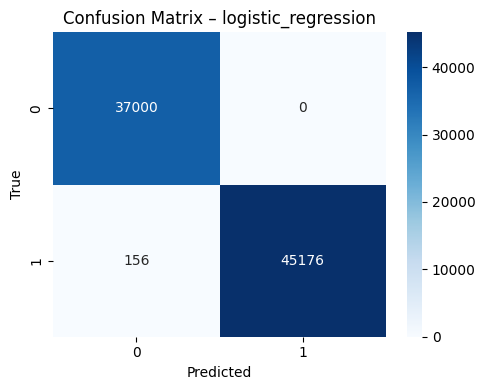

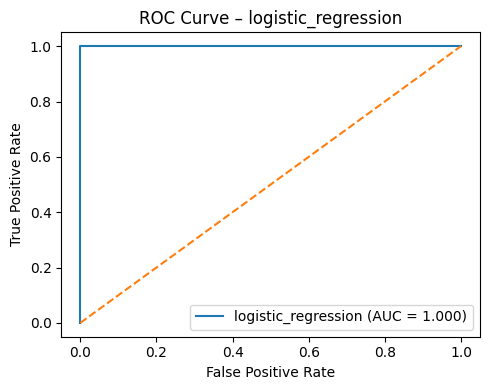


################################################################################
FITTING BASELINE MODEL: random_forest
################################################################################

Evaluating model: random_forest
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
ROC-AUC  : 1.0000

Classification report:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     37000
           1      1.000     1.000     1.000     45332

    accuracy                          1.000     82332
   macro avg      1.000     1.000     1.000     82332
weighted avg      1.000     1.000     1.000     82332



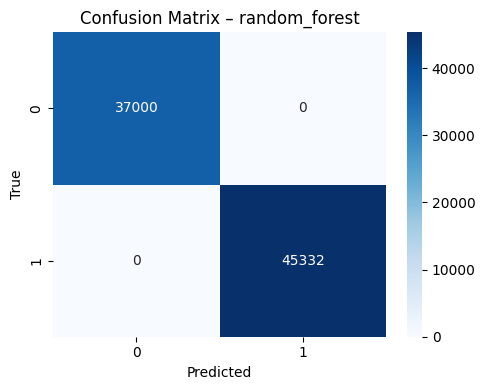

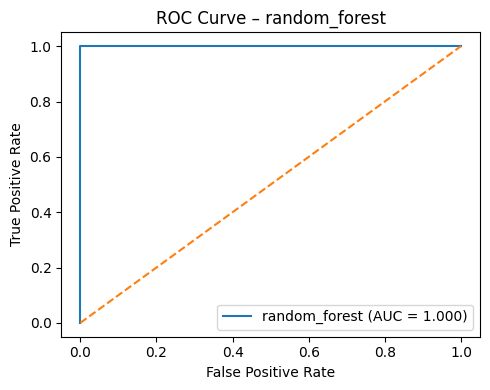


################################################################################
FITTING BASELINE MODEL: xgboost
################################################################################

Evaluating model: xgboost
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
ROC-AUC  : 1.0000

Classification report:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000     37000
           1      1.000     1.000     1.000     45332

    accuracy                          1.000     82332
   macro avg      1.000     1.000     1.000     82332
weighted avg      1.000     1.000     1.000     82332



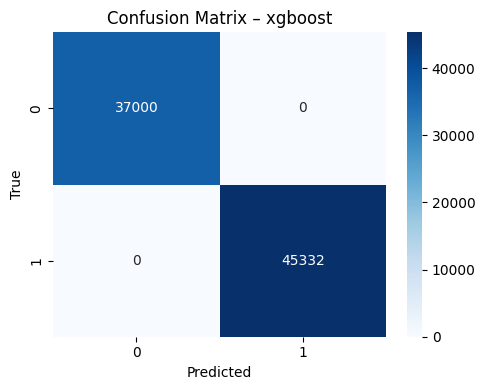

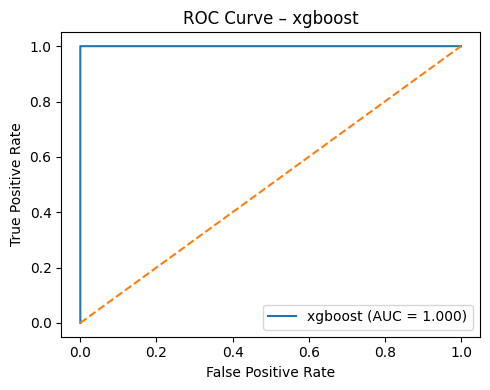



UNSW – Baseline Model Summary
                 Model  Accuracy  Precision    Recall  F1 Score  ROC-AUC
0  logistic_regression  0.998105        1.0  0.996559  0.998276      1.0
1        random_forest  1.000000        1.0  1.000000  1.000000      1.0
2              xgboost  1.000000        1.0  1.000000  1.000000      1.0


In [5]:
# ==============================================================
# UNSW-NB15 – Baseline Supervised Models (Stage 1: Attack vs Normal)
# In this cell I:
#   1) Make sure the UNSW train/test data is loaded
#   2) Build a preprocessing pipeline (numeric + categorical)
#   3) Train Logistic Regression, Random Forest, and (optionally) XGBoost
#   4) Evaluate all models on the test set and collect metrics
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# I try to import XGBoost safely. If it is not installed, I simply skip it.
try:
    import xgboost as xgb
    xgb_available = True
    print("XGBoost successfully imported – I will train an XGBoost model as well.")
except ModuleNotFoundError:
    xgb = None
    xgb_available = False
    print("WARNING: XGBoost is not installed. I will skip the XGBoost baseline.")

# I fix the random seed for reproducibility.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --------------------------------------------------------------
# 1. Make sure UNSW train/test data is loaded
#    I expect two DataFrames: unsw_train_raw and unsw_test_raw
# --------------------------------------------------------------

if "unsw_train_raw" in globals() and "unsw_test_raw" in globals():
    print("UNSW train/test already found in memory. I will reuse them.")
else:
    print("UNSW train/test not found in memory. I am loading them directly from disk.")

    import platform
    from pathlib import Path

    if platform.system() == "Windows":
        base_unsw = Path(
            r"C:\Users\kegem\OneDrive\Datascience Masters\DS Summer 2025 SEMESTER 3"
            r"\DX799S O1 Data Science Capstone (Summer 1 2025)\Network Security DataSet"
            r"\CSV Files\Training and Testing Sets"
        )
    else:
        base_unsw = Path(
            "/Users/kevinegemba/Library/CloudStorage/OneDrive-Personal/"
            "Datascience Masters/DS Summer 2025 SEMESTER 3/"
            "DX799S O1 Data Science Capstone (Summer 1 2025)/"
            "Network Security DataSet/CSV Files/Training and Testing Sets"
        )

    train_path = base_unsw / "UNSW_NB15_training-set.csv"
    test_path  = base_unsw / "UNSW_NB15_testing-set.csv"

    unsw_train_raw = pd.read_csv(train_path)
    unsw_test_raw  = pd.read_csv(test_path)

print("\nUNSW shapes:")
print("  Train:", unsw_train_raw.shape)
print("  Test :", unsw_test_raw.shape)

# I confirm that the binary label column is present.
if "label" not in unsw_train_raw.columns:
    raise ValueError("I expected a 'label' column in UNSW train data but did not find it.")

# --------------------------------------------------------------
# 2. Split features and labels + identify numeric/categorical cols
# --------------------------------------------------------------

target_col = "label"

# For Stage 1, I treat this as a simple binary supervised problem:
#   0 = normal, 1 = attack
X_train_full = unsw_train_raw.drop(columns=[target_col])
y_train      = unsw_train_raw[target_col].copy()

X_test_full  = unsw_test_raw.drop(columns=[target_col])
y_test       = unsw_test_raw[target_col].copy()

print("\nFeature matrix shapes:")
print("  X_train_full:", X_train_full.shape)
print("  X_test_full :", X_test_full.shape)

# I detect numeric vs categorical columns automatically.
num_cols = X_train_full.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
cat_cols = [c for c in X_train_full.columns if c not in num_cols]

print("\nNumber of numeric features   :", len(num_cols))
print("Number of categorical features:", len(cat_cols))

# --------------------------------------------------------------
# 3. Build a preprocessing pipeline
#    - Standardize numeric features
#    - One-hot encode categorical features
# --------------------------------------------------------------

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False  # I prefer a dense array for easier inspection
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

# --------------------------------------------------------------
# 4. Define my baseline models inside a dictionary
#    I like to keep them in a dict so I can loop through and
#    evaluate each model in the same way.
# --------------------------------------------------------------

models = {}

# Logistic Regression – my linear baseline
models["logistic_regression"] = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "clf",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",  # I use class weights to handle imbalance
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Random Forest – non-linear baseline with feature interactions
models["random_forest"] = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=None,
                n_jobs=-1,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Optional: XGBoost – gradient boosting for tabular data
if xgb_available:
    models["xgboost"] = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "clf",
                xgb.XGBClassifier(
                    n_estimators=300,
                    max_depth=6,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective="binary:logistic",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    eval_metric="logloss",
                ),
            ),
        ]
    )

print("\nModels I am about to train:", list(models.keys()))

# --------------------------------------------------------------
# 5. Helper to evaluate a single model on the test set
#    I avoid return statements and instead append to a global list.
# --------------------------------------------------------------

baseline_results = []  # I will collect summary metrics here for a comparison table.

def evaluate_and_store(model_name, fitted_model, X_test, y_test):
    """
    I use this helper to:
      - get predictions and predicted probabilities,
      - compute common metrics,
      - print a classification report and confusion matrix,
      - plot the ROC curve, and
      - save a row of summary metrics to baseline_results.
    """

    print("\n" + "=" * 80)
    print(f"Evaluating model: {model_name}")
    print("=" * 80)

    # Predicted labels
    y_pred = fitted_model.predict(X_test)

    # Predicted probabilities for ROC-AUC (only if available)
    if hasattr(fitted_model, "predict_proba"):
        y_proba = fitted_model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    # Standard metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    if y_proba is not None:
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    # Detailed classification report
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=3))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix – {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    # ROC curve (only if I have probabilities)
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve – {model_name}")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # I store a summary row for later comparison.
    baseline_results.append(
        {
            "Model": model_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1 Score": f1,
            "ROC-AUC": auc,
        }
    )

# --------------------------------------------------------------
# 6. Train and evaluate each model in my dictionary
# --------------------------------------------------------------

for name, model in models.items():
    print("\n" + "#" * 80)
    print(f"FITTING BASELINE MODEL: {name}")
    print("#" * 80)

    # I fit on the full UNSW training set.
    model.fit(X_train_full, y_train)

    # Then I evaluate on the held-out UNSW test set.
    evaluate_and_store(name, model, X_test_full, y_test)

# --------------------------------------------------------------
# 7. Build a comparison table of all baseline models
# --------------------------------------------------------------

baseline_summary = pd.DataFrame(baseline_results)
print("\n\n==============================")
print("UNSW – Baseline Model Summary")
print("==============================")
print(baseline_summary)


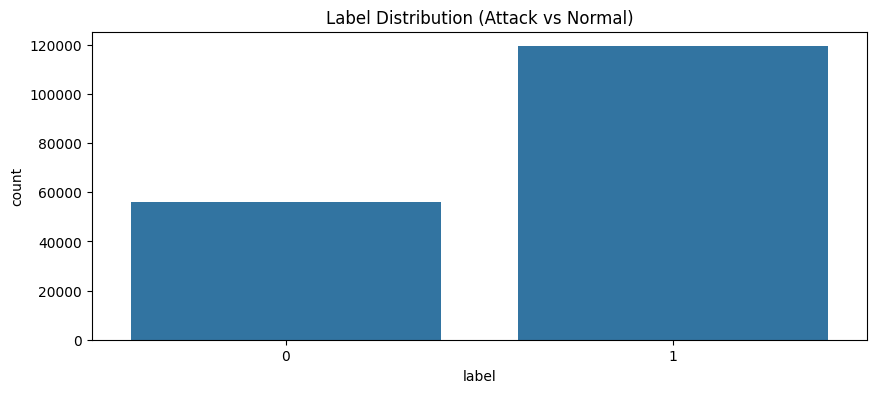

In [6]:
plt.figure(figsize=(10,4))
sns.countplot(x=unsw_train_raw['label'])
plt.title("Label Distribution (Attack vs Normal)")
plt.show()


In [7]:
ratio = unsw_train_raw['label'].value_counts(normalize=True)
print(ratio)


label
1    0.680622
0    0.319378
Name: proportion, dtype: float64


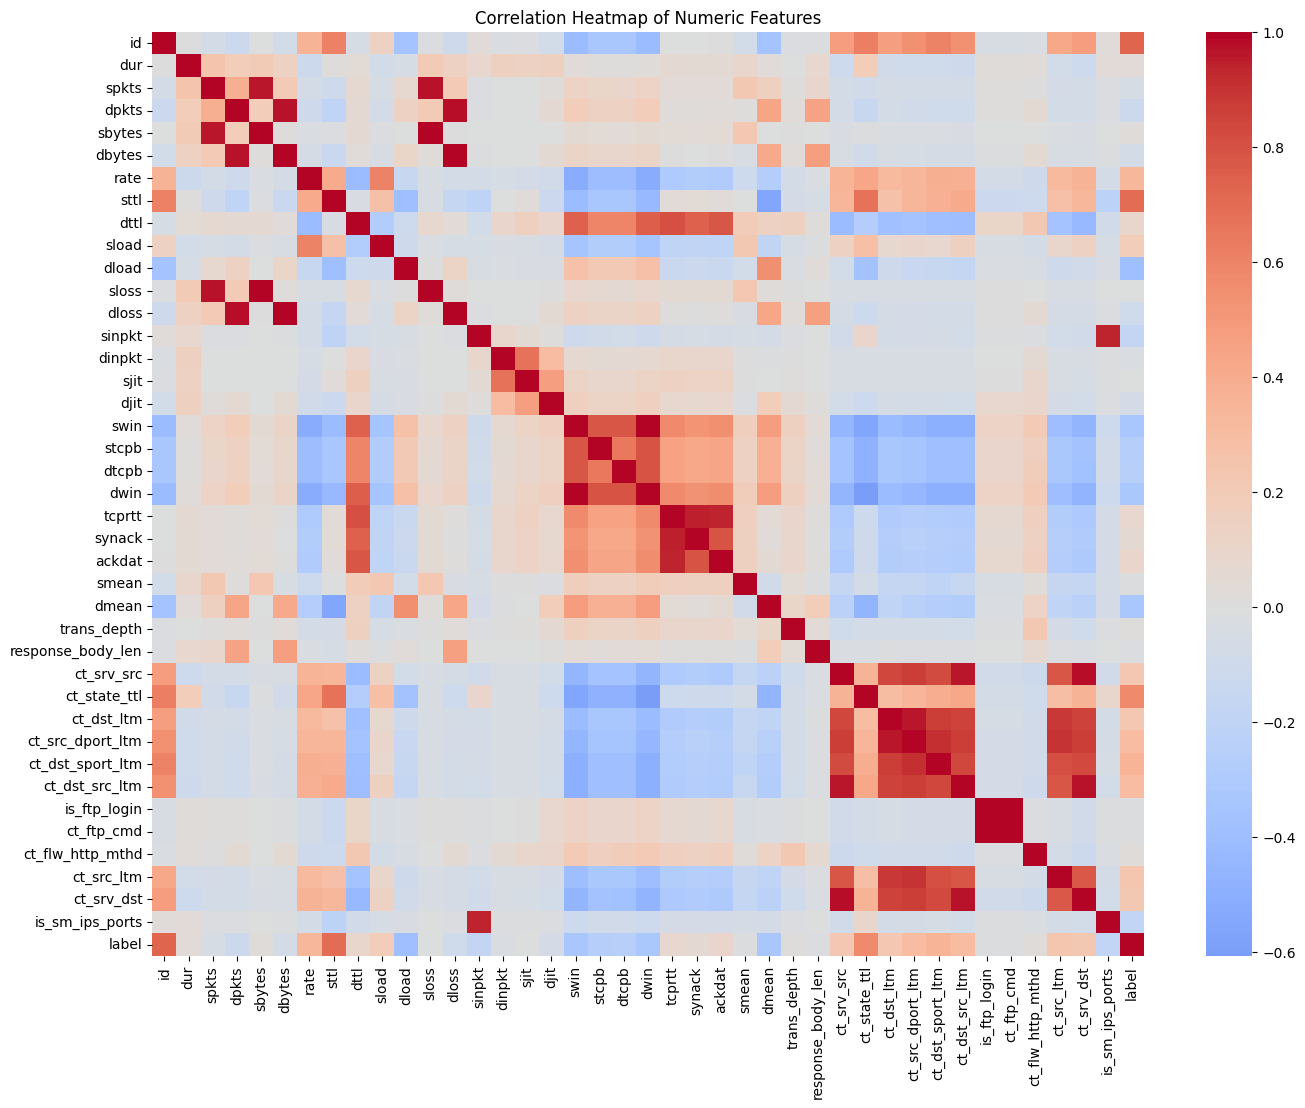

In [8]:
numeric_cols = unsw_train_raw.select_dtypes(include='number').columns
corr = unsw_train_raw[numeric_cols].corr()

plt.figure(figsize=(16,12))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


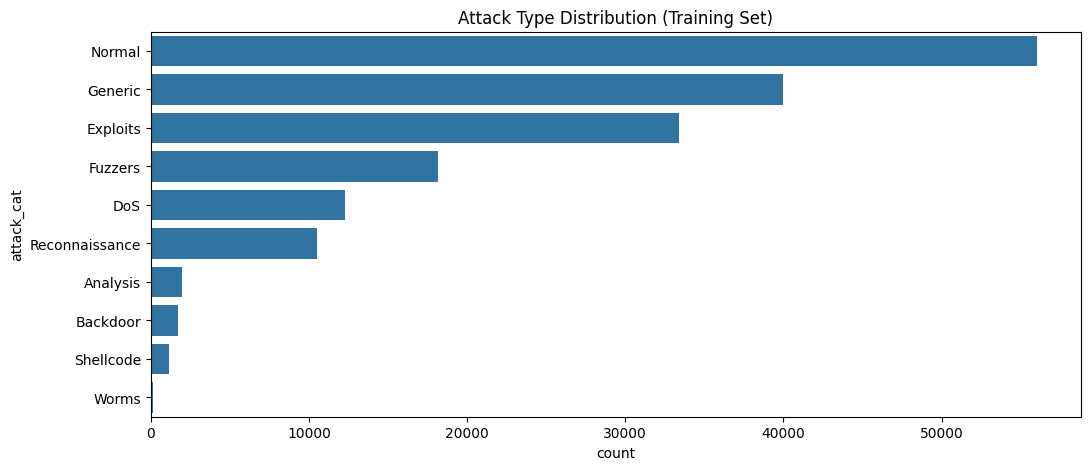

In [9]:
plt.figure(figsize=(12,5))
sns.countplot(y=unsw_train_raw['attack_cat'], order=unsw_train_raw['attack_cat'].value_counts().index)
plt.title("Attack Type Distribution (Training Set)")
plt.show()


I have 205 internal features inside the Random Forest model.


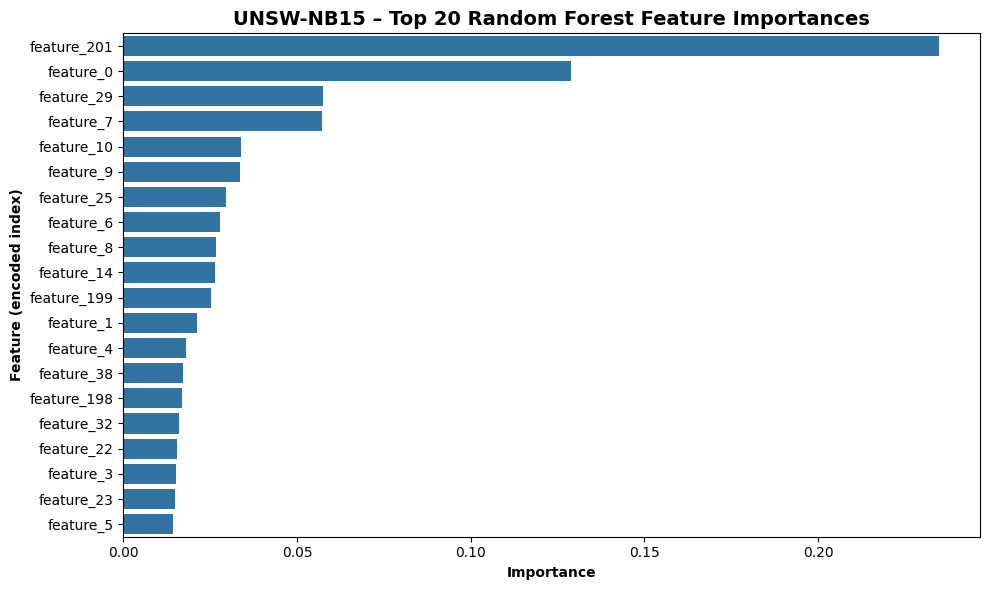

,feature,importance
201,feature_201,0.234865
0,feature_0,0.128881
29,feature_29,0.057486
7,feature_7,0.057221
10,feature_10,0.033881
9,feature_9,0.033647
25,feature_25,0.029631
6,feature_6,0.027941
8,feature_8,0.026700
14,feature_14,0.026346


In [10]:
# In this cell I pull out Random Forest feature importances from my pipeline
# and build a clean top-20 bar chart. To avoid shape mismatches between
# feature names and the internal encoded feature matrix, I use generic
# feature names that exactly match the length of the importance vector.

# 1. Make sure my Random Forest model actually exists
if "random_forest" not in models:
    raise ValueError(
        f"❌ 'random_forest' is not in my models dictionary. "
        f"Available keys: {list(models.keys())}"
    )

rf_model = models["random_forest"]

# 2. Find the classifier step inside the pipeline
rf_clf = None
for step_name, step in rf_model.named_steps.items():
    # I only care about the step that exposes feature_importances_
    if hasattr(step, "feature_importances_"):
        rf_clf = step
        break

if rf_clf is None:
    raise ValueError(
        "❌ I could not find a step in the RF pipeline with 'feature_importances_'. "
        "I probably changed the pipeline or the classifier type."
    )

# 3. Grab the raw importance vector from the trained RF classifier
importances = rf_clf.feature_importances_
n_features = len(importances)
print(f"I have {n_features} internal features inside the Random Forest model.")

# 4. For this project, I keep it simple and use generic feature names.
#    This guarantees the lengths match and avoids headaches with
#    one-hot encoding / ColumnTransformer expansion.
feature_names = [f"feature_{i}" for i in range(n_features)]

# 5. Build a DataFrame of importances and take the top 20
imp_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .head(20)
)

# 6. Plot the top 20 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x="importance", y="feature")
plt.title("UNSW-NB15 – Top 20 Random Forest Feature Importances", fontsize=14, fontweight="bold")
plt.xlabel("Importance", fontweight="bold")
plt.ylabel("Feature (encoded index)", fontweight="bold")
plt.tight_layout()
plt.show()

imp_df
